In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.interpolate import CubicSpline
import corner

import utils.lib.nn_studio as nn_studio
import utils.lib.chiral_potential as chiral_potential
import utils.lib.granada_phases as granada
import utils.lib.auxiliary as aux
import utils.lib.lec_values as lec_values
from utils.lib.constants import *

In [2]:
#%matplotlib widget
#plt.close("all")

# Notebook per i plot

In [3]:
# Iniziamo caricando le catene salvate.
# Aggiungiamo anche un piccolo flag per assicurarci di non aver salvato una catena flat, ma è un eccesso di zelo.

LO_1S0_chain = np.load("results/full_chain_LO_1S0.npy")
assert len(LO_1S0_chain.shape) == 3, f"La catena LO_1S0 dovrebbe avere shape (nsteps, nwalkers, ndim), invece la sua shape è {full_chain_LO_1S0.shape}"
LO_3S1_chain = np.load("results/full_chain_LO_3S1.npy")
assert len(LO_3S1_chain.shape) == 3, f"La catena LO_3S1 dovrebbe avere shape (nsteps, nwalkers, ndim), invece la sua shape è {full_chain_LO_3S1.shape}"
NLO_1S0_chain = np.load("results/full_chain_NLO_1S0.npy")
assert len(NLO_1S0_chain.shape) == 3, f"La catena NLO_1S0 dovrebbe avere shape (nsteps, nwalkers, ndim), invece la sua shape è {full_chain_NLO_1S0.shape}"
NLO_3S1_chain = np.load("results/full_chain_NLO_3S1.npy")
assert len(NLO_3S1_chain.shape) == 3, f"La catena NLO_3S1 dovrebbe avere shape (nsteps, nwalkers, ndim), invece la sua shape è {full_chain_NLO_3S1.shape}"

In [4]:
# Caricando le catene dalla cartella, perdiamo l'accesso ai metodi del sampler di emcee.
# Quindi, ci tocca riscriverli da zero:

def next_power_of_two(n):
    i = 1
    while i < n:
        i = i << 1 # Questa operazione è uno shift di un bit!
    return i


def calculate_acf_1d(x):
    """
    Usa la FFT per calcolare la auto-correlation function normalizzata di un array 1D.
    """
    x = np.atleast_1d(x)
    p = next_power_of_two(len(x))
    F = np.fft.fft(x - np.mean(x), n=2*p)
    ACF = np.fft.ifft(F * np.conjugate(F))[:len(x)].real
    ACF /= ACF[0] # Normalizzazione
    return ACF # È un array!


def sokal_window(taus, c):
    """
    Funzione ausiliaria, emcee stima le auto-correlazioni così.
    """
    m = np.arange(len(taus)) < c * taus
    if np.any(m):
        return np.argmin(m)
    return len(taus) - 1


def calculate_autocorr_time(full_chain, c=5.0):
    """
    Port di sampler.get_autocorr_time, ossia restituisce l'array di tempi di autocorrelazione.
    Non dà warning per catene troppo corte, in compenso restituisce effettivamente l'array sempre.

    chain   : (nsteps, nwalkers, ndim)
    c       : costante per la finestra di Sokal (default è 5.0)
    """
    nsteps, nwalkers, ndim = full_chain.shape
    tau = np.empty(ndim)
    # L'idea è per ogni parametro di fare la media della auto-correlation function (ACF) su tutti i walkers.
    for parameter in range(ndim):
        ACF = np.zeros(nsteps)
        for walker in range(nwalkers):
            ACF += calculate_acf_1d(full_chain[:, walker, parameter])
        ACF /= nwalkers
        taus = 2.0 * np.cumsum(ACF) - 1.0
        window = sokal_window(taus, c) # È uno scalare, in particolare un indice!
        tau[parameter] = taus[window]
    return tau


def process_chain(full_chain, discard=0, thin=1, flat=False):
    """
    Port di sampler.get_chain, ossia applica discard e thin.
    Da usare prima di fare i corner plots.

    chain   : (nsteps, nwalkers, ndim)
    discard : numero di step da scartare all'inizio come burn-in
    thin    : per mantenere solo ogni thin-esimo step
    flat    : se True, fa un merge dei primi due assi, restituendo (nsteps * nwalkers, ndim)
    """
    processed = full_chain[discard::thin] # Semplice slicing
    if flat:
        nsteps, nwalkers, ndim = processed.shape
        processed = processed.reshape(nsteps * nwalkers, ndim) # Semplice reshaping
    return processed

# (grazie Opus)

In [5]:
# Carichiamo anche i dati sperimentali per fare i fit finali:

T_Lab = granada.Tlabs 

shift_1S0 = granada.delta_1S0
shift_1S0_error = granada.delta_1S0_errors

shift_3S1 = granada.delta_3S1
shift_3S1_error = granada.delta_3S1_errors

shift_3D1 = granada.delta_3D1
shift_3D1_error = granada.delta_3D1_errors

shift_mix = granada.delta_3E1
shift_mix_error = granada.delta_3E1_errors

nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=30, mesh_type="gauleg_infinite")
nn.Tlabs = T_Lab
_, channel_1S0 = nn.lookup_channel_idx(l=0,ll=0,s=0,j=0) 
_, channel_3S1 = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1)

#

# LO:

## Run LO-1S0

In [6]:
# Leggiamo i parametri della run:

nsteps_LO_1S0, nwalkers_LO_1S0, ndim_LO_1S0 = LO_1S0_chain.shape
param_names_LO_1S0 = [r"$C_{^1S_0}$ [$10^4$ GeV$^{-2}$]"]

In [7]:
# Otteniamo i tempi di auto-correlazione:

tau_LO_1S0 = calculate_autocorr_time(LO_1S0_chain)
print("\nTempi di autocorrelazione:", tau_LO_1S0)

if np.any(nsteps_LO_1S0 < 50 * tau_LO_1S0):
    print(f"\n\n!!  Nota bene che la catena è più corta di 50 tau: servirebbero {int(50*np.max(tau_LO_1S0))} step, invece ne hai {nsteps_LO_1S0}  !!\n")

discard_LO_1S0 = 5 * int(max(tau_LO_1S0))
print(f"\nConseguente numero di step di termalizzazione: {discard_LO_1S0} step")

thin_LO_1S0 = int(min(tau_LO_1S0))
print(f"\nConseguente numero di step per il thinning: {thin_LO_1S0} step\n")


Tempi di autocorrelazione: [10.13606188]

Conseguente numero di step di termalizzazione: 50 step

Conseguente numero di step per il thinning: 10 step



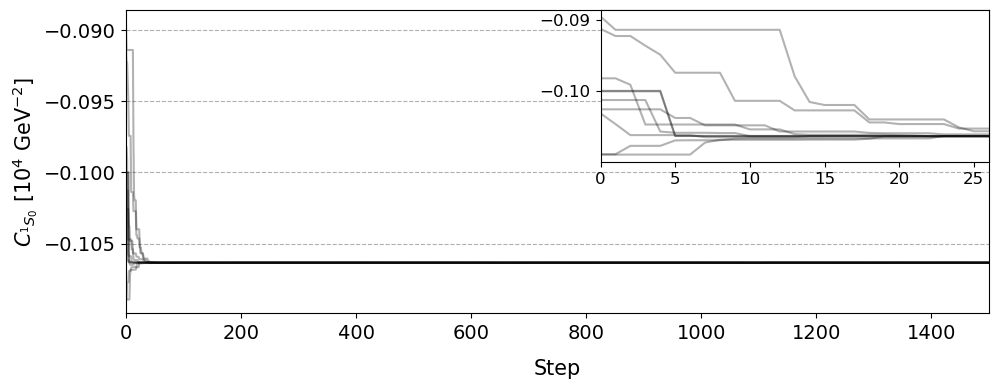

In [8]:
# Disegniamo i trace plots:

fig, axes = plt.subplots(ndim_LO_1S0, figsize=(10, 4*ndim_LO_1S0), sharex=True)

# Routine per uniformare il codice successivo:
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
elif isinstance(axes, plt.Axes):
    axes = [axes]

# Disegno vero e proprio:
for parameter in range(ndim_LO_1S0):
    ax = axes[parameter]
    for walker in range(nwalkers_LO_1S0):
        ax.plot(LO_1S0_chain[:, walker, parameter], "k", alpha=0.3)
    ax.set_ylabel(param_names_LO_1S0[parameter], fontsize=15)
    ax.tick_params(axis="y", labelsize=14)
    ax.set_xlim(0, len(LO_1S0_chain))
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.grid(axis="y", linestyle="--")

    # Sintassi per gli inset:
    ax_ins = ax.inset_axes([0.55, 0.5, 0.45, 0.5])
    ax_ins.plot(LO_1S0_chain[:discard_LO_1S0//2+2, :, parameter], "k", alpha=0.3)
    ax_ins.set_xlim(0, discard_LO_1S0//2+1)
    ax_ins.tick_params(labelsize=12) # Numeri dello zoom (meglio 10 per non sovrapporsi)
    #ax.indicate_inset_zoom(ax_ins, edgecolor="black")

axes[-1].set_xlabel("Step", fontsize=15)
axes[-1].xaxis.set_label_coords(0.5, -0.15)
axes[-1].tick_params(axis="x", labelsize=14)
#plt.suptitle("Tracce dei cammini dei walker")
plt.tight_layout()
#fig.savefig("figures/trace_LO_1S0.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

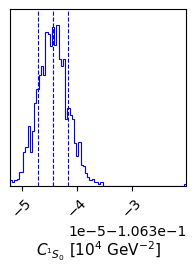

In [9]:
# Disegniamo il corner plot triviale:

flat_samples_LO_1S0 = process_chain(LO_1S0_chain, discard=discard_LO_1S0, thin=thin_LO_1S0, flat=True)

fig = plt.figure(figsize=(3*ndim_LO_1S0, 3*ndim_LO_1S0))

corner_fig = corner.corner(
    flat_samples_LO_1S0,
    labels=param_names_LO_1S0,
    show_titles=False, # Impostiamo False per non litigare con le cifre significative nei titoli. [OPINABILE]
    # Purtroppo, non c'è neppure modo di litigare con le cifre significative delle ticks, che lasciamo di default.
    title_fmt=".4f",
    title_kwargs={"fontsize": 12},
    fig=fig,
    plot_datapoints=True,
    bins=80,
    smooth=2.0,
    #smooth1d=1.0, # Personalmente non mi piace [OPINABILE]
    color="b", # "deeppink"
    data_kwargs={
        "color": "lightgray",
        "alpha": 0.7, # (default 0.1)
        "ms": 2.0 # Diametro dei datapoints (default 2)
    },
    max_n_ticks=4,
    quantiles=[0.16, 0.5, 0.84], # Nei diagonali, sono le linee trattegiate verticali
    levels=(0.68, 0.95), # Nei non-diagonali, sono le linee di livello continue
    label_kwargs={"fontsize": 11}, # Non vedo nessuna differenza nel cambiare il labelpad(?)
    hist_kwargs={"linewidth": 0.8}, # Spessore della cresta dell'istogramma (default 1)
    contour_kwargs={"linewidths": 0.8}, # Spessore delle curve di livello (default 1)
    use_math_text=False, # Se True, permette di usare la notazione scientifica nelle ticks
    #plot_contours=True, # Soppresso se scegliamo i levels manualmente
    #fill_contours=True, # Riempie le curve di livello
    #plot_density=True, # Già true di default
)

# Routine per cambiare lo spessore delle linee trattegiate verticali dei diagonali:
for ax in np.array(corner_fig.axes):
    for line in ax.lines:
        if line.get_linestyle() == "--":
            line.set_linewidth(0.8)

#fig.suptitle(r"Corner Plot per LO - $^1S_0$", fontsize=16)
#fig.savefig("figures/corner_LO_1S0.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

##

## Run LO-3S1

In [10]:
# Leggiamo i parametri della run:

nsteps_LO_3S1, nwalkers_LO_3S1, ndim_LO_3S1 = LO_3S1_chain.shape
param_names_LO_3S1 = [r"$C_{^3S_1}$ [$10^4$ GeV$^{-2}$]"]

In [11]:
# Otteniamo i tempi di auto-correlazione:

tau_LO_3S1 = calculate_autocorr_time(LO_3S1_chain)
print("\nTempi di autocorrelazione:", tau_LO_3S1)

if np.any(nsteps_LO_3S1 < 50 * tau_LO_3S1):
    print(f"\n\n!!  Nota bene che la catena è più corta di 50 tau: servirebbero {int(50*np.max(tau_LO_3S1))} step, invece ne hai {nsteps_LO_3S1}  !!\n")

discard_LO_3S1 = 5 * int(max(tau_LO_3S1))
print(f"\nConseguente numero di step di termalizzazione: {discard_LO_3S1} step")

thin_LO_3S1 = int(min(tau_LO_3S1))
print(f"\nConseguente numero di step per il thinning: {thin_LO_3S1} step\n")


Tempi di autocorrelazione: [16.54748814]

Conseguente numero di step di termalizzazione: 80 step

Conseguente numero di step per il thinning: 16 step



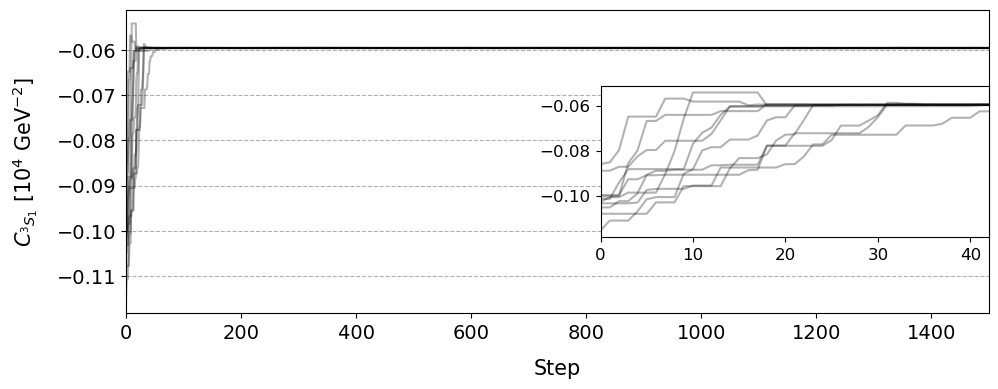

In [12]:
# Disegniamo i trace plots:

fig, axes = plt.subplots(ndim_LO_3S1, figsize=(10, 4*ndim_LO_3S1), sharex=True)

# Routine per uniformare il codice successivo:
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
elif isinstance(axes, plt.Axes):
    axes = [axes]

# Disegno vero e proprio:
for parameter in range(ndim_LO_3S1):
    ax = axes[parameter]
    for walker in range(nwalkers_LO_3S1):
        ax.plot(LO_3S1_chain[:, walker, parameter], "k", alpha=0.3)
    ax.set_ylabel(param_names_LO_3S1[parameter], fontsize=15)
    ax.tick_params(axis="y", labelsize=14)
    ax.set_xlim(0, len(LO_3S1_chain))
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.grid(axis="y", linestyle="--")

    # Sintassi per gli inset:
    ax_ins = ax.inset_axes([0.55, 0.25, 0.45, 0.5])
    ax_ins.plot(LO_3S1_chain[:discard_LO_3S1//2+3, :, parameter], "k", alpha=0.3)
    ax_ins.set_xlim(0, discard_LO_3S1//2+2)
    ax_ins.tick_params(labelsize=12) # Numeri dello zoom (meglio 10 per non sovrapporsi)
    #ax.indicate_inset_zoom(ax_ins, edgecolor="black")

axes[-1].set_xlabel("Step", fontsize=15)
axes[-1].xaxis.set_label_coords(0.5, -0.15)
axes[-1].tick_params(axis="x", labelsize=14)
#plt.suptitle("Tracce dei cammini dei walker")
plt.tight_layout()
#fig.savefig("figures/trace_LO_3S1.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

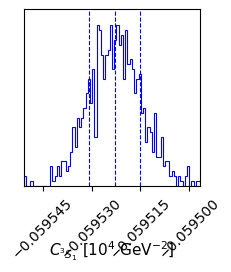

In [13]:
# Disegniamo il corner plot triviale:

flat_samples_LO_3S1 = process_chain(LO_3S1_chain, discard=discard_LO_3S1, thin=thin_LO_3S1, flat=True)

fig = plt.figure(figsize=(3*ndim_LO_3S1, 3*ndim_LO_3S1))

corner_fig = corner.corner(
    flat_samples_LO_3S1,
    labels=param_names_LO_3S1,
    show_titles=False, # Impostiamo False per non litigare con le cifre significative nei titoli. [OPINABILE]
    # Purtroppo, non c'è neppure modo di litigare con le cifre significative delle ticks, che lasciamo di default.
    title_fmt=".4f",
    title_kwargs={"fontsize": 12},
    fig=fig,
    plot_datapoints=True,
    bins=80,
    smooth=2.0,
    #smooth1d=1.0, # Personalmente non mi piace [OPINABILE]
    color="b", # "deeppink"
    data_kwargs={
        "color": "lightgray",
        "alpha": 0.7, # (default 0.1)
        "ms": 2.0 # Diametro dei datapoints (default 2)
    },
    max_n_ticks=4,
    quantiles=[0.16, 0.5, 0.84], # Nei diagonali, sono le linee trattegiate verticali
    levels=(0.68, 0.95), # Nei non-diagonali, sono le linee di livello continue
    label_kwargs={"fontsize": 11}, # Non vedo nessuna differenza nel cambiare il labelpad(?)
    hist_kwargs={"linewidth": 0.8}, # Spessore della cresta dell'istogramma (default 1)
    contour_kwargs={"linewidths": 0.8}, # Spessore delle curve di livello (default 1)
    use_math_text=False, # Se True, permette di usare la notazione scientifica nelle ticks
    #plot_contours=True, # Soppresso se scegliamo i levels manualmente
    #fill_contours=True, # Riempie le curve di livello
    #plot_density=True, # Già true di default
)

# Routine per cambiare lo spessore delle linee trattegiate verticali dei diagonali:
for ax in np.array(corner_fig.axes):
    for line in ax.lines:
        if line.get_linestyle() == "--":
            line.set_linewidth(0.8)

#fig.suptitle(r"Corner Plot per LO - $^3S_1$", fontsize=16)
#fig.savefig("figures/corner_LO_3S1.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

##

## Residui LO

In [32]:
# Utilizzando i parametri inferiti, calcoliamo le previsioni teoriche:

nn.V = chiral_potential.two_nucleon_potential("LO",Lambda=500.0)

C_1S0_LO_median = np.median(flat_samples_LO_1S0)
C_1S0_LO_sigma = np.std(flat_samples_LO_1S0)
C_3S1_LO_median = np.median(flat_samples_LO_3S1)
C_3S1_LO_sigma = np.std(flat_samples_LO_3S1)

print(f"[trascurando le unità di misura]\n")
print(f"\nLO - C_1S0:\t{C_1S0_LO_median:.6f} +- {C_1S0_LO_sigma:.6f}")
print(f"LO - C_3S1:\t{C_3S1_LO_median:.6f} +- {C_3S1_LO_sigma:.6f}\n")

LO_lecs = {}
LO_lecs["C_1S0"] = C_1S0_LO_median
LO_lecs["C_3S1"] = C_3S1_LO_median
nn.lecs = LO_lecs

nn.compute_Tmtx(channel_1S0, verbose=False)
data_LO_1S0 = nn.phase_shifts[0]
nn.compute_Tmtx(channel_3S1, verbose=False)
data_LO_3S1 = nn.phase_shifts[0][:, 0]
data_LO_3D1 = nn.phase_shifts[0][:, 1]
data_LO_mix = nn.phase_shifts[0][:, 2]

[trascurando le unità di misura]


LO - C_1S0:	-0.106345 +- 0.000003
LO - C_3S1:	-0.059523 +- 0.000008



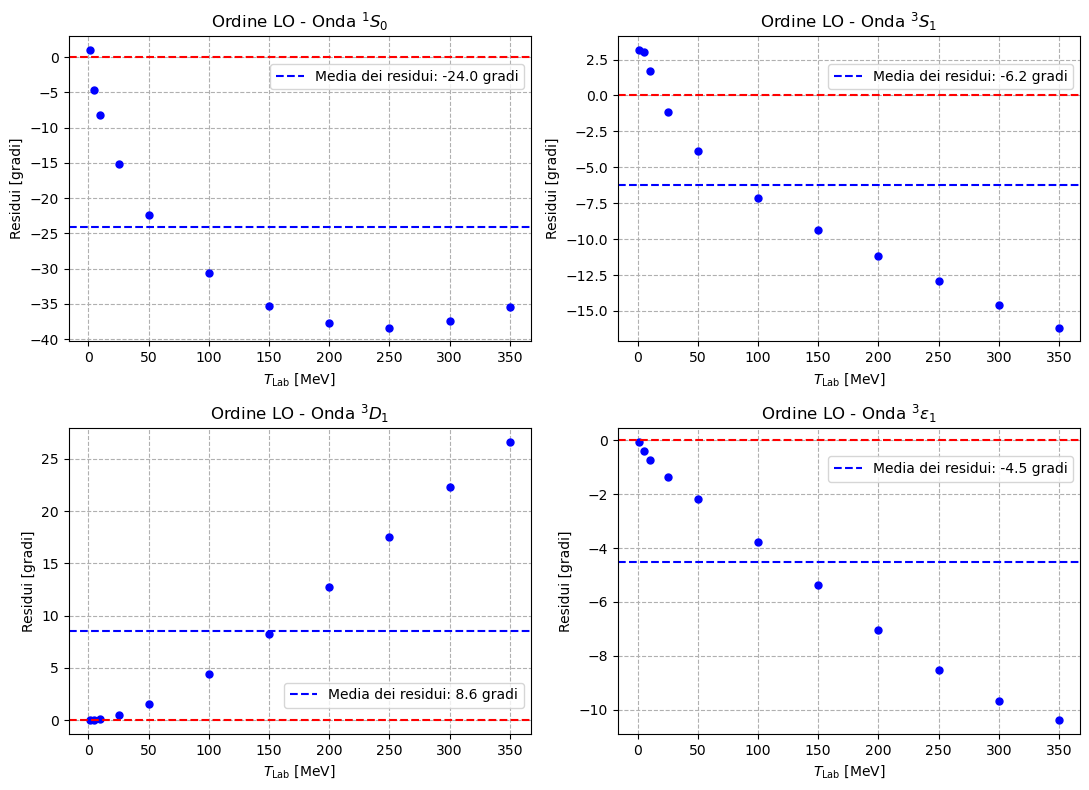

In [15]:
# Calcoliamo i residui:

LO_residuals = []
LO_residuals.append(shift_1S0 - data_LO_1S0)
LO_residuals.append(shift_3S1 - data_LO_3S1)
LO_residuals.append(shift_3D1 - data_LO_3D1)
LO_residuals.append(shift_mix - data_LO_mix)
LO_means_res = []
for i in range(4):
    LO_means_res.append(np.mean(LO_residuals[i]))
titles = [r"$^1S_0$", r"$^3S_1$", r"$^3D_1$", r"$^3\varepsilon_1$"]

figure, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
for i in range(4):
    ax = axes[i]
    ax.plot(T_Lab, LO_residuals[i], marker = ".", linestyle = "None", color = "b", markersize = 10.)
    ax.axhline(LO_means_res[i], linestyle= "--", color = "b", label=f"Media dei residui: {LO_means_res[i]:.1f} gradi")
    ax.axhline(0, linestyle= "--", color = "r")
    ax.set_xlabel(r"$T_\mathrm{Lab}$ [MeV]")
    ax.set_ylabel(r"Residui [gradi]")
    ax.set_title(f"Ordine LO - Onda {titles[i]}")
    if i==2:
        ax.legend(loc="upper right", bbox_to_anchor=(1.0,0.19))
    else:
        ax.legend(loc="upper right", bbox_to_anchor=(1.0,0.93))
    ax.grid(linestyle = "--")
plt.tight_layout()
#fig.savefig("figures/residuals_NLO.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

#

# NLO:

## Run NLO-1S0

In [16]:
# Leggiamo i parametri della run:

nsteps_NLO_1S0, nwalkers_NLO_1S0, ndim_NLO_1S0 = NLO_1S0_chain.shape
param_names_NLO_1S0 = [r"$C_{^1S_0}$ [$10^4$ GeV$^{-2}$]", r"$D_{^1S_0}$ [$10^4$ GeV$^{-4}$]"]

In [17]:
# Sappiamo questa run specifica è la più instabile e dei walkers potrebbero perdersi.
# Capiamo quali sono gli indici dei walker patologici guardando i path uno ad uno:
#for i in range(NLO_1S0_chain.shape[1]):
#    plt.plot(NLO_1S0_chain[:, i, 0], alpha=0.4)
#    plt.title("Walker numero {}".format(i))
#    plt.xlabel("Step")
#    plt.ylabel(param_names[0])
#    plt.show()

# ATTUALMENTE, è il walker di indice 7 a perdersi, e solo lui.
# Rimuoviamolo dalla catena, prima di fare i corner plots:
NLO_1S0_chain_clean = np.delete(NLO_1S0_chain, 7, axis=1)
# Nota che i tempi di auto-correlazione in generale cambiano, ma di davvero poco in questo caso quindi non ce ne preoccupiamo.

In [18]:
# Otteniamo i tempi di auto-correlazione:

tau_NLO_1S0 = calculate_autocorr_time(NLO_1S0_chain_clean)
print("\nTempi di autocorrelazione:", tau_NLO_1S0)

if np.any(nsteps_NLO_1S0 < 50 * tau_NLO_1S0):
    print(f"\n\n!!  Nota bene che la catena è più corta di 50 tau: servirebbero {int(50*np.max(tau_NLO_1S0))} step, invece ne hai {nsteps_NLO_1S0}  !!\n")

discard_NLO_1S0 = 5 * int(max(tau_NLO_1S0))
print(f"\nConseguente numero di step di termalizzazione: {discard_NLO_1S0} step")

thin_NLO_1S0 = int(min(tau_NLO_1S0))
print(f"\nConseguente numero di step per il thinning: {thin_NLO_1S0} step\n")


Tempi di autocorrelazione: [19.30170798 39.1850965 ]

Conseguente numero di step di termalizzazione: 195 step

Conseguente numero di step per il thinning: 19 step



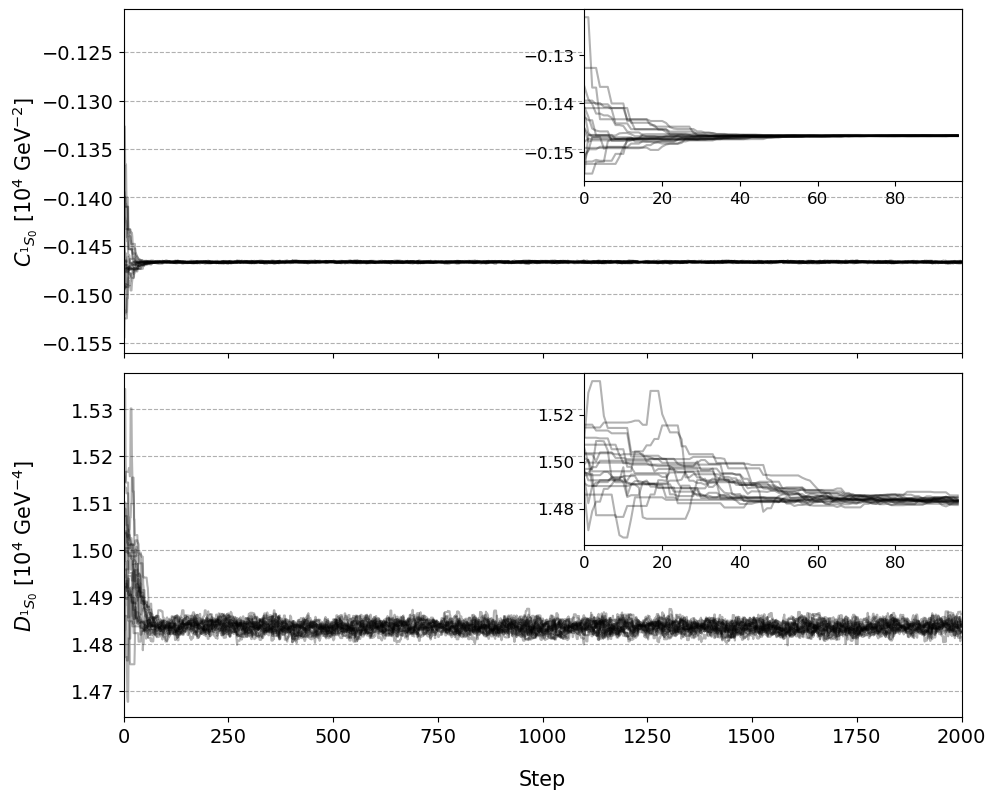

In [19]:
# Disegniamo i trace plots:

fig, axes = plt.subplots(ndim_NLO_1S0, figsize=(10, 4*ndim_NLO_1S0), sharex=True)

# Routine per uniformare il codice successivo:
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
elif isinstance(axes, plt.Axes):
    axes = [axes]

# Disegno vero e proprio:
for parameter in range(ndim_NLO_1S0):
    ax = axes[parameter]
    for walker in range(NLO_1S0_chain_clean.shape[1]):
        ax.plot(NLO_1S0_chain_clean[:, walker, parameter], "k", alpha=0.3)
    ax.set_ylabel(param_names_NLO_1S0[parameter], fontsize=15)
    ax.tick_params(axis="y", labelsize=14)
    ax.set_xlim(0, len(NLO_1S0_chain_clean))
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.grid(axis="y", linestyle="--")

    # Sintassi per gli inset:
    ax_ins = ax.inset_axes([0.55, 0.5, 0.45, 0.5])
    ax_ins.plot(NLO_1S0_chain_clean[:discard_NLO_1S0//2, :, parameter], "k", alpha=0.3)
    ax_ins.set_xlim(0, discard_NLO_1S0//2)
    ax_ins.tick_params(labelsize=12) # Numeri dello zoom (meglio 10 per non sovrapporsi)
    #ax.indicate_inset_zoom(ax_ins, edgecolor="black")

axes[-1].set_xlabel("Step", fontsize=15)
axes[-1].xaxis.set_label_coords(0.5, -0.15)
axes[-1].tick_params(axis="x", labelsize=14)
#plt.suptitle("Tracce dei cammini dei walker")
plt.tight_layout()
#fig.savefig("figures/trace_NLO_1S0.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

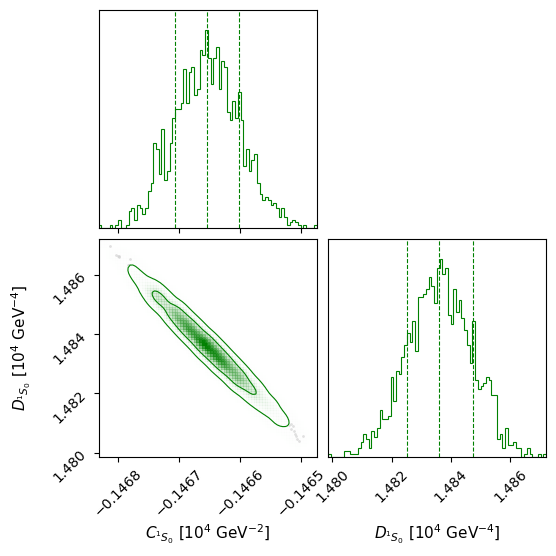

In [20]:
# Disegniamo i corner plots:

flat_samples_NLO_1S0 = process_chain(NLO_1S0_chain_clean, discard=discard_NLO_1S0, thin=thin_NLO_1S0, flat=True)

fig = plt.figure(figsize=(3*ndim_NLO_1S0, 3*ndim_NLO_1S0))

corner_fig = corner.corner(
    flat_samples_NLO_1S0,
    labels=param_names_NLO_1S0,
    show_titles=False, # Impostiamo False per non litigare con le cifre significative nei titoli. [OPINABILE]
    # Purtroppo, non c'è neppure modo di litigare con le cifre significative delle ticks, che lasciamo di default.
    title_fmt=".4f",
    title_kwargs={"fontsize": 12},
    fig=fig,
    plot_datapoints=True,
    bins=80,
    smooth=2.0,
    #smooth1d=1.0, # Personalmente non mi piace [OPINABILE]
    color="g", # "purple"
    data_kwargs={
        "color": "lightgray",
        "alpha": 0.7, # (default 0.1)
        "ms": 2.0 # Diametro dei datapoints (default 2)
    },
    max_n_ticks=4,
    quantiles=[0.16, 0.5, 0.84], # Nei diagonali, sono le linee trattegiate verticali
    levels=(0.68, 0.95), # Nei non-diagonali, sono le linee di livello continue
    label_kwargs={"fontsize": 11}, # Non vedo nessuna differenza nel cambiare il labelpad(?)
    hist_kwargs={"linewidth": 0.8}, # Spessore della cresta dell'istogramma (default 1)
    contour_kwargs={"linewidths": 0.8}, # Spessore delle curve di livello (default 1)
    use_math_text=False, # Se True, permette di usare la notazione scientifica nelle ticks
    #plot_contours=True, # Soppresso se scegliamo i levels manualmente
    #fill_contours=True, # Riempie le curve di livello
    #plot_density=True, # Già true di default
)

# Routine per cambiare lo spessore delle linee trattegiate verticali dei diagonali:
for ax in np.array(corner_fig.axes):
    for line in ax.lines:
        if line.get_linestyle() == "--":
            line.set_linewidth(0.8)

#fig.suptitle(r"Corner Plot per NLO - $^1S_0$", fontsize=16)
#fig.savefig("figures/corner_NLO_1S0.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

##

## Run NLO-3S1

In [21]:
# Leggiamo i parametri della run:

nsteps_NLO_3S1, nwalkers_NLO_3S1, ndim_NLO_3S1 = NLO_3S1_chain.shape
param_names_NLO_3S1 = [r"$C_{^3S_1}$ [$10^4$ GeV$^{-2}$]", r"$D_{^3S_1}$ [$10^4$ GeV$^{-4}$]", r"$D_{^3\varepsilon_1}$ [$10^4$ GeV$^{-4}$]"]

In [22]:
# Otteniamo i tempi di auto-correlazione:

tau_NLO_3S1 = calculate_autocorr_time(NLO_3S1_chain)
print("\nTempi di autocorrelazione:", tau_NLO_3S1)

if np.any(nsteps_NLO_3S1 < 50 * tau_NLO_3S1):
    print(f"\n\n!!  Nota bene che la catena è più corta di 50 tau: servirebbero {int(50*np.max(tau_NLO_3S1))} step, invece ne hai {nsteps_NLO_3S1}  !!\n")

discard_NLO_3S1 = 5 * int(max(tau_NLO_3S1))
print(f"\nConseguente numero di step di termalizzazione: {discard_NLO_3S1} step")

thin_NLO_3S1 = int(min(tau_NLO_3S1))
print(f"\nConseguente numero di step per il thinning: {thin_NLO_3S1} step\n")

# Il problema di questa run, invece, è che il tempo di auto-correlazione continua ad aumentare col numero di step.
# Ho scritto il codice affinché possiamo usare il tempo di auto-correlazione e fare tutto, sebbene "ammettendo" che la run sia troppo corta.


Tempi di autocorrelazione: [73.34879144 77.69105728 73.2782367 ]


!!  Nota bene che la catena è più corta di 50 tau: servirebbero 3884 step, invece ne hai 3000  !!


Conseguente numero di step di termalizzazione: 385 step

Conseguente numero di step per il thinning: 73 step



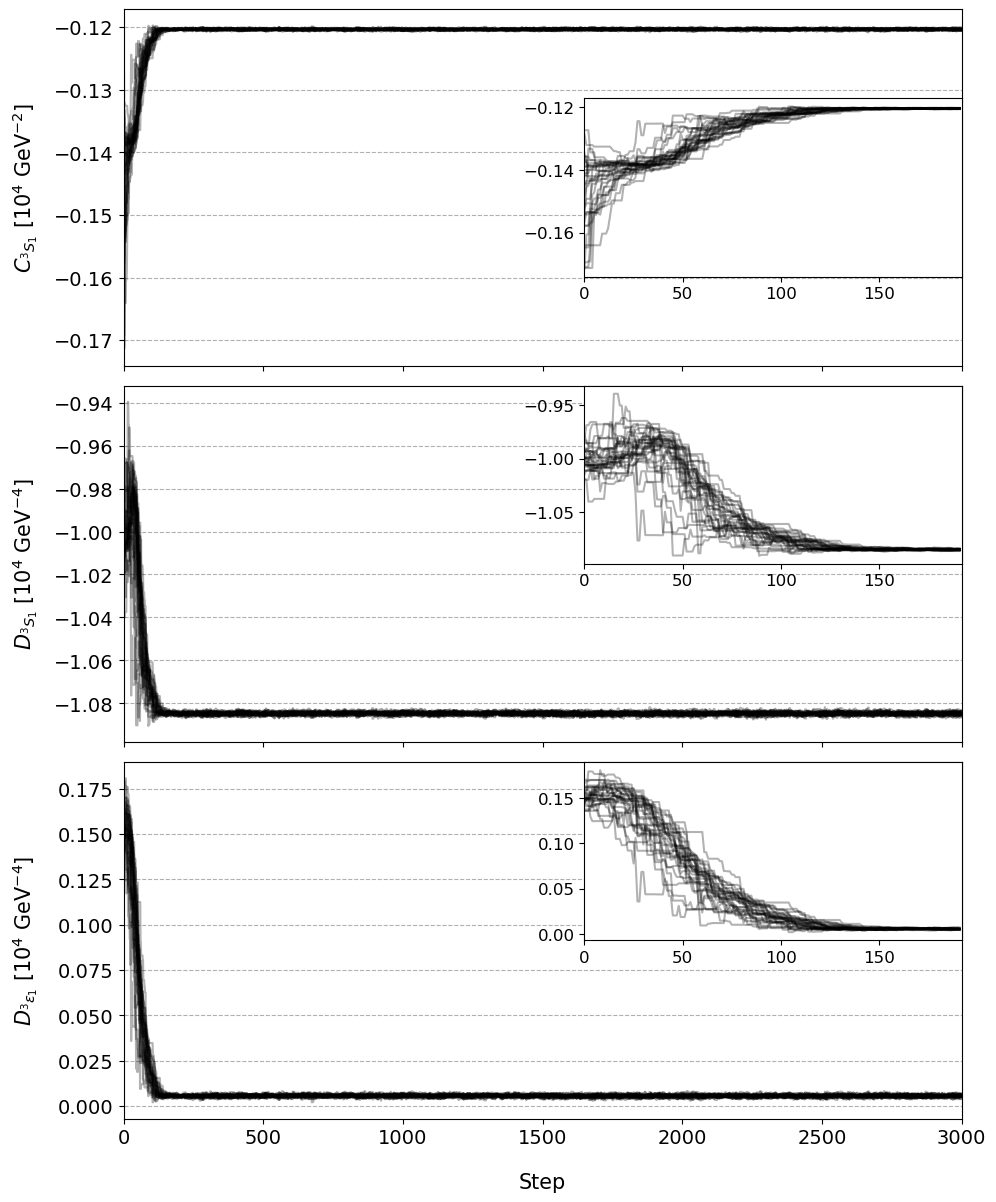

In [23]:
# Disegniamo i trace plots:

fig, axes = plt.subplots(ndim_NLO_3S1, figsize=(10, 4*ndim_NLO_3S1), sharex=True)

# Routine per uniformare il codice successivo:
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
elif isinstance(axes, plt.Axes):
    axes = [axes]

# Disegno vero e proprio:
for parameter in range(ndim_NLO_3S1):
    ax = axes[parameter]
    for walker in range(nwalkers_NLO_3S1):
        ax.plot(NLO_3S1_chain[:, walker, parameter], "k", alpha=0.3)
    ax.set_ylabel(param_names_NLO_3S1[parameter], fontsize=15)
    ax.tick_params(axis="y", labelsize=14)
    ax.set_xlim(0, len(NLO_3S1_chain))
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.grid(axis="y", linestyle="--")

    # Sintassi per gli inset:
    if parameter == 0:
        ax_ins = ax.inset_axes([0.55, 0.25, 0.45, 0.5])
    else:
        ax_ins = ax.inset_axes([0.55, 0.5, 0.45, 0.5])
    ax_ins.plot(NLO_3S1_chain[:discard_NLO_3S1//2, :, parameter], "k", alpha=0.3)
    ax_ins.set_xlim(0, discard_NLO_3S1//2)
    ax_ins.tick_params(labelsize=12) # Numeri dello zoom (meglio 10 per non sovrapporsi)
    #ax.indicate_inset_zoom(ax_ins, edgecolor="black")

axes[-1].set_xlabel("Step", fontsize=15)
axes[-1].xaxis.set_label_coords(0.5, -0.15)
axes[-1].tick_params(axis="x", labelsize=14)
#plt.suptitle("Tracce dei cammini dei walker")
plt.tight_layout()
#fig.savefig("figures/trace_NLO_3S1.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

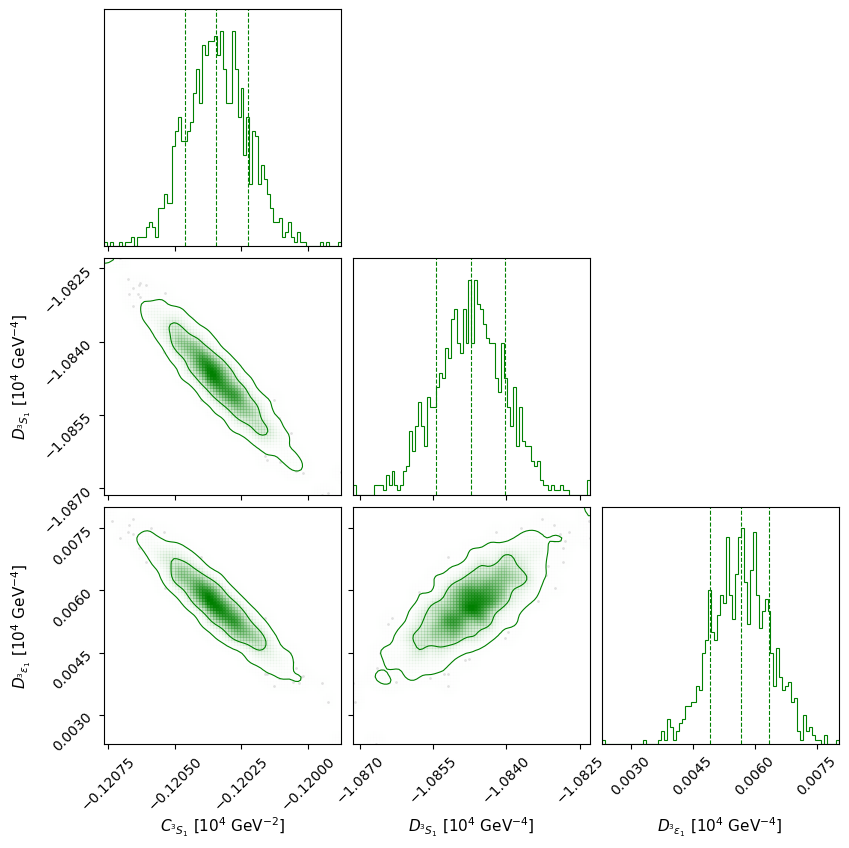

In [24]:
# Disegniamo i corner plots:

flat_samples_NLO_3S1 = process_chain(NLO_3S1_chain, discard=discard_NLO_3S1, thin=thin_NLO_3S1, flat=True)

fig = plt.figure(figsize=(3*ndim_NLO_3S1, 3*ndim_NLO_3S1))

corner_fig = corner.corner(
    flat_samples_NLO_3S1,
    labels=param_names_NLO_3S1,
    show_titles=False, # Impostiamo False per non litigare con le cifre significative nei titoli. [OPINABILE]
    # Purtroppo, non c'è neppure modo di litigare con le cifre significative delle ticks, che lasciamo di default.
    title_fmt=".4f",
    title_kwargs={"fontsize": 12},
    fig=fig,
    plot_datapoints=True,
    bins=80,
    smooth=2.0,
    #smooth1d=1.0, # Personalmente non mi piace [OPINABILE]
    color="g", # "purple"
    data_kwargs={
        "color": "lightgray",
        "alpha": 0.7, # (default 0.1)
        "ms": 2.0 # Diametro dei datapoints (default 2)
    },
    max_n_ticks=4,
    quantiles=[0.16, 0.5, 0.84], # Nei diagonali, sono le linee trattegiate verticali
    levels=(0.68, 0.95), # Nei non-diagonali, sono le linee di livello continue
    label_kwargs={"fontsize": 11}, # Non vedo nessuna differenza nel cambiare il labelpad(?)
    hist_kwargs={"linewidth": 0.8}, # Spessore della cresta dell'istogramma (default 1)
    contour_kwargs={"linewidths": 0.8}, # Spessore delle curve di livello (default 1)
    use_math_text=False, # Se True, permette di usare la notazione scientifica nelle ticks
    #plot_contours=True, # Soppresso se scegliamo i levels manualmente
    #fill_contours=True, # Riempie le curve di livello
    #plot_density=True, # Già true di default
)

# Routine per cambiare lo spessore delle linee trattegiate verticali dei diagonali:
for ax in np.array(corner_fig.axes):
    for line in ax.lines:
        if line.get_linestyle() == "--":
            line.set_linewidth(0.8)

#fig.suptitle(r"Corner Plot per NLO - $^3S_1$", fontsize=16)
#fig.savefig("figures/corner_NLO_3S1.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

##

## Residui NLO

In [31]:
# Utilizzando i parametri inferiti, calcoliamo le previsioni teoriche:

nn.V = chiral_potential.two_nucleon_potential("NLO",Lambda=500.0)

C_1S0_NLO_median = np.median(flat_samples_NLO_1S0[:,0])
C_1S0_NLO_sigma = np.std(flat_samples_NLO_1S0[:,0])
D_1S0_NLO_median = np.median(flat_samples_NLO_1S0[:,1])
D_1S0_NLO_sigma = np.std(flat_samples_NLO_1S0[:,1])
C_3S1_NLO_median = np.median(flat_samples_NLO_3S1[:,0])
C_3S1_NLO_sigma = np.std(flat_samples_NLO_3S1[:,0])
D_3S1_NLO_median = np.median(flat_samples_NLO_3S1[:,1])
D_3S1_NLO_sigma = np.std(flat_samples_NLO_3S1[:,1])
D_mix_NLO_median = np.median(flat_samples_NLO_3S1[:,2])
D_mix_NLO_sigma = np.std(flat_samples_NLO_3S1[:,2])

print(f"[trascurando le unità di misura]\n")
print(f"\nNLO - C_1S0:\t{C_1S0_NLO_median:.4f} +- {C_1S0_NLO_sigma:.4f}")
print(f"NLO - C_3S1:\t{C_3S1_NLO_median:.4f} +- {C_3S1_NLO_sigma:.4f}")
print(f"NLO - D_1S0:\t{D_1S0_NLO_median:.4f} +- {D_1S0_NLO_sigma:.4f}")
print(f"NLO - D_3S1:\t{D_3S1_NLO_median:.4f} +- {D_3S1_NLO_sigma:.4f}")
print(f"NLO - D_mix:\t{D_mix_NLO_median:.4f} +- {D_mix_NLO_sigma:.4f}\n")

NLO_lecs = {}
NLO_lecs["C_1S0"] = C_1S0_NLO_median
NLO_lecs["D_1S0"] = D_1S0_NLO_median
NLO_lecs["C_3S1"] = C_3S1_NLO_median
NLO_lecs["D_3S1"] = D_3S1_NLO_median
NLO_lecs["D_3S1-3D1"] = D_mix_NLO_median
NLO_lecs["D_1P1"] = 0.0
NLO_lecs["D_3P0"] = 0.0
NLO_lecs["D_3P1"] = 0.0
NLO_lecs["D_3P2"] = 0.0
nn.lecs = NLO_lecs

nn.compute_Tmtx(channel_1S0, verbose=False)
data_NLO_1S0 = nn.phase_shifts[0]
nn.compute_Tmtx(channel_3S1, verbose=False)
data_NLO_3S1 = nn.phase_shifts[0][:, 0]
data_NLO_3D1 = nn.phase_shifts[0][:, 1]
data_NLO_mix = nn.phase_shifts[0][:, 2]

[trascurando le unità di misura]


NLO - C_1S0:	-0.1467 +- 0.0001
NLO - C_3S1:	-0.1203 +- 0.0001
NLO - D_1S0:	1.4836 +- 0.0011
NLO - D_3S1:	-1.0847 +- 0.0007
NLO - D_mix:	0.0057 +- 0.0007



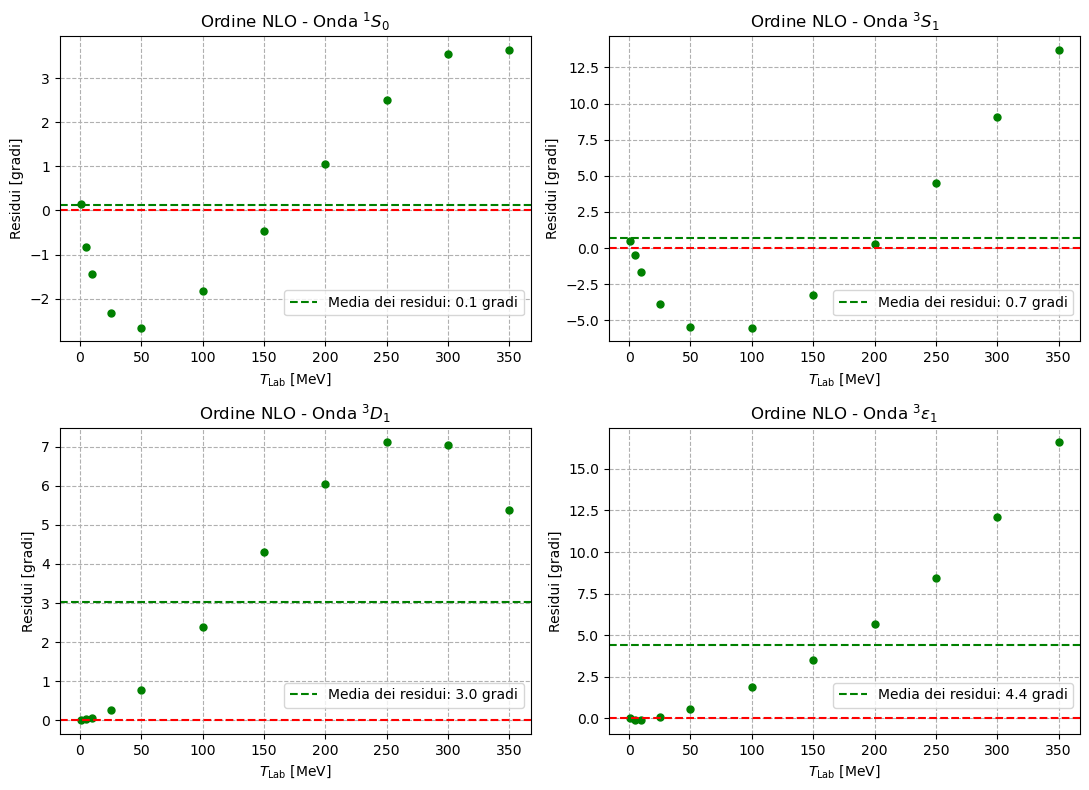

In [26]:
# Calcoliamo i residui:

NLO_residuals = []
NLO_residuals.append(shift_1S0 - data_NLO_1S0)
NLO_residuals.append(shift_3S1 - data_NLO_3S1)
NLO_residuals.append(shift_3D1 - data_NLO_3D1)
NLO_residuals.append(shift_mix - data_NLO_mix)
NLO_means_res = []
for i in range(4):
    NLO_means_res.append(np.mean(NLO_residuals[i]))
titles = [r"$^1S_0$", r"$^3S_1$", r"$^3D_1$", r"$^3\varepsilon_1$"]

figure, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
for i in range(4):
    ax = axes[i]
    ax.plot(T_Lab, NLO_residuals[i], marker = ".", linestyle = "None", color = "g", markersize = 10.)
    ax.axhline(NLO_means_res[i], linestyle= "--", color = "g", label=f"Media dei residui: {NLO_means_res[i]:.1f} gradi")
    ax.axhline(0, linestyle= "--", color = "r")
    ax.set_xlabel(r"$T_\mathrm{Lab}$ [MeV]")
    ax.set_ylabel(r"Residui [gradi]")
    ax.set_title(f"Ordine NLO - Onda {titles[i]}")
    ax.legend(loc="upper right", bbox_to_anchor=(1.0,0.19))
    ax.grid(linestyle = "--")
plt.tight_layout()
#fig.savefig("figures/residuals_NLO.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

#

# Fit per l'appendice

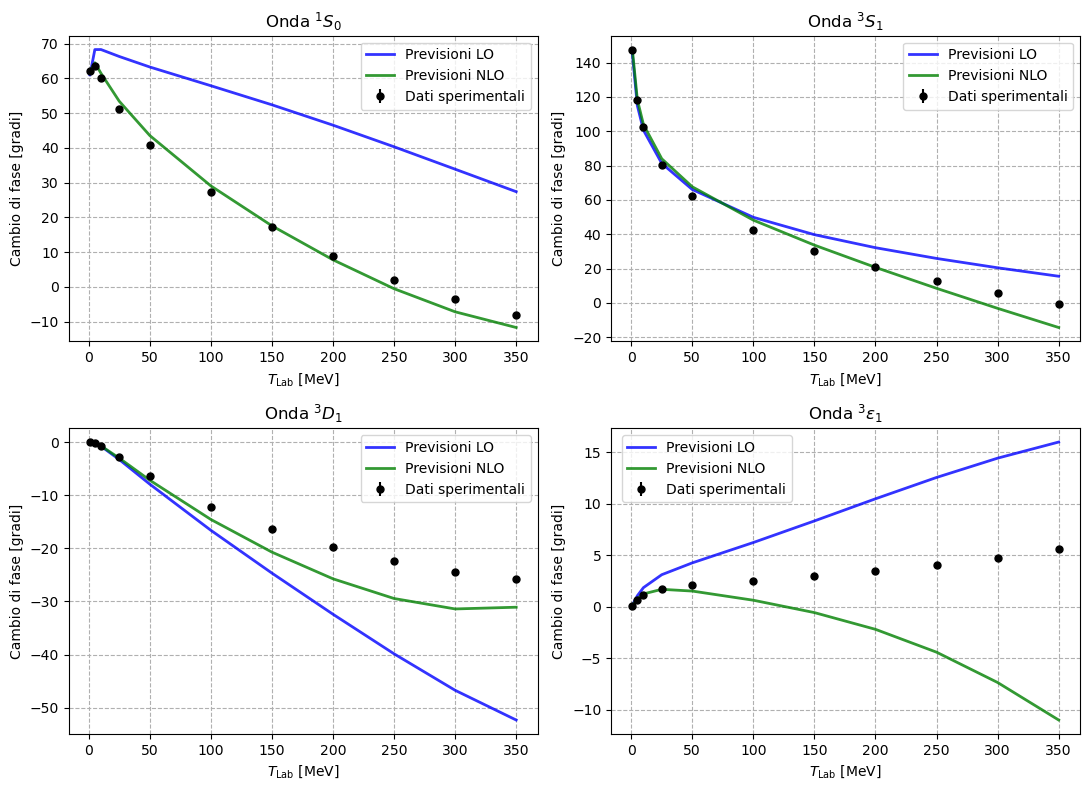

In [27]:
# Grafichiamo le previsioni teoriche contro i dati sperimentali:

exp_shifts = []
exp_shifts.append(shift_1S0)
exp_shifts.append(shift_3S1)
exp_shifts.append(shift_3D1)
exp_shifts.append(shift_mix)

exp_errors = []
exp_errors.append(shift_1S0_error)
exp_errors.append(shift_3S1_error)
exp_errors.append(shift_3D1_error)
exp_errors.append(shift_mix_error)

teo_LO = []
teo_LO.append(data_LO_1S0)
teo_LO.append(data_LO_3S1)
teo_LO.append(data_LO_3D1)
teo_LO.append(data_LO_mix)

teo_NLO = []
teo_NLO.append(data_NLO_1S0)
teo_NLO.append(data_NLO_3S1)
teo_NLO.append(data_NLO_3D1)
teo_NLO.append(data_NLO_mix)

figure, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
for i in range(4):
    ax = axes[i]
    ax.errorbar(T_Lab, exp_shifts[i], yerr = exp_errors[i], label = "Dati sperimentali", color="k", ls="none", marker="o", markersize=5.)
    ax.plot(T_Lab, teo_LO[i], label = "Previsioni LO", color="b", alpha=0.8, lw=2)
    ax.plot(T_Lab, teo_NLO[i], label = "Previsioni NLO", color="g", alpha=0.8, lw=2)
    ax.set_xlabel(r"$T_\mathrm{Lab}$ [MeV]")
    ax.set_ylabel(r"Cambio di fase [gradi]")
    ax.set_title(f"Onda {titles[i]}")
    if i==3:
        ax.legend(loc="upper right", bbox_to_anchor=(0.40,1.0))
    else:
        ax.legend(loc="upper right", bbox_to_anchor=(1.0,1.0))
    ax.grid(linestyle = "--")
plt.tight_layout()
#fig.savefig("figures/fits_NLO.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
# Calcoliamo infine le previsioni per il deutone:

nn_Q = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=30, mesh_type="gauleg_finite")
nn_Q.Tlabs = T_Lab
#_, channel_3S1 = nn_Q.lookup_channel_idx(l=0,ll=2,s=1,j=1)
E_obs = -2.224
Q_obs = 0.286

# LO:
nn_Q.V = chiral_potential.two_nucleon_potential("LO",Lambda=500.0)
nn_Q.lecs = LO_lecs

# Energia:
_, mu = nn_Q.lab2rel(0, 0)
N = 2 * nn_Q.Np
H = np.zeros((N, N))
T = np.zeros((N, N))
ww = np.hstack((nn_Q.wmesh, nn_Q.wmesh))
pp = np.hstack((nn_Q.pmesh, nn_Q.pmesh))
V = nn_Q.setup_Vmtx(channel_3S1[0])[0]
for i, p_bra in enumerate(pp):
    for j, p_ket in enumerate(pp):
        if i == j:
            T[i, j] = p_bra**2 / (2 * mu)
        V[i, j] = V[i, j] * p_bra * p_ket * np.sqrt(ww[i] * ww[j])
H = T + V
eigvals, eigvecs = linalg.eigh(H)
srt = np.argsort(eigvals)
E_LO = eigvals[srt[0]]

# Quadrupolo:
phi_gs = eigvecs[:, srt[0]]
psi_gs = phi_gs / (pp * np.sqrt(ww))
u = psi_gs[:nn_Q.Np]
w = psi_gs[nn_Q.Np:]
if u[np.argmax(np.abs(u))] < 0:
    u *= -1
    w *= -1
P_S_LO = np.sum(nn_Q.wmesh * nn_Q.pmesh**2 * u**2)
P_D_LO = np.sum(nn_Q.wmesh * nn_Q.pmesh**2 * w**2)
idx = np.argsort(nn_Q.pmesh)
p = nn_Q.pmesh[idx]
spline_u = CubicSpline(p, u[idx])
spline_w = CubicSpline(p, w[idx])
du = spline_u(p, 1)
dw = spline_w(p, 1)
u = u[idx]
w = w[idx]
wmesh = nn_Q.wmesh[idx]
SD_term = (-np.sqrt(8)/20) * (p**2 * dw * du + 3 * p * w * du)
DD_term = (-1/20) * (p**2 * dw**2 + 6 * w**2)
Q_LO = np.sum(wmesh * (SD_term + DD_term))
Q_LO *= hbarc**2
if Q_LO < 0:
    Q_LO *= -1

# NLO:
nn_Q.V = chiral_potential.two_nucleon_potential("NLO",Lambda=500.0)
nn_Q.lecs = NLO_lecs

# Energia:
_, mu = nn_Q.lab2rel(0, 0)
N = 2 * nn_Q.Np
H = np.zeros((N, N))
T = np.zeros((N, N))
ww = np.hstack((nn_Q.wmesh, nn_Q.wmesh))
pp = np.hstack((nn_Q.pmesh, nn_Q.pmesh))
V = nn_Q.setup_Vmtx(channel_3S1[0])[0]
for i, p_bra in enumerate(pp):
    for j, p_ket in enumerate(pp):
        if i == j:
            T[i, j] = p_bra**2 / (2 * mu)
        V[i, j] = V[i, j] * p_bra * p_ket * np.sqrt(ww[i] * ww[j])
H = T + V
eigvals, eigvecs = linalg.eigh(H)
srt = np.argsort(eigvals)
E_NLO = eigvals[srt[0]]

# Quadrupolo:
phi_gs = eigvecs[:, srt[0]]
psi_gs = phi_gs / (pp * np.sqrt(ww))
u = psi_gs[:nn_Q.Np]
w = psi_gs[nn_Q.Np:]
if u[np.argmax(np.abs(u))] < 0:
    u *= -1
    w *= -1
P_S_NLO = np.sum(nn_Q.wmesh * nn_Q.pmesh**2 * u**2)
P_D_NLO = np.sum(nn_Q.wmesh * nn_Q.pmesh**2 * w**2)
idx = np.argsort(nn_Q.pmesh)
p = nn_Q.pmesh[idx]
spline_u = CubicSpline(p, u[idx])
spline_w = CubicSpline(p, w[idx])
du = spline_u(p, 1)
dw = spline_w(p, 1)
u = u[idx]
w = w[idx]
wmesh = nn_Q.wmesh[idx]
SD_term = (-np.sqrt(8)/20) * (p**2 * dw * du + 3 * p * w * du)
DD_term = (-1/20) * (p**2 * dw**2 + 6 * w**2)
Q_NLO = np.sum(wmesh * (SD_term + DD_term))
Q_NLO *= hbarc**2
if Q_NLO < 0:
    Q_NLO *= -1

In [38]:
print(f"\nEnergia del deutone in LO:\t{E_LO:.3f} MeV")
print(f"Energia del deutone in NLO:\t{E_NLO:.3f} MeV")
print(f"Energia del deutone nominale:\t{E_obs:.3f} MeV\n")

print(f"\nPercentuale di onda D nel deutone in LO:\t{P_D_LO * 100:.2f}%")
print(f"Percentuale di onda D nel deutone in NLO:\t{P_D_NLO * 100:.2f}%")
print(f"Percentuale di onda D nel deutone nominale:\t~ 4%\n")

print(f"\nQuadrupolo elettrico del deutone in LO:\t\t{Q_LO:.3f} fm^2")
print(f"Quadrupolo elettrico del deutone in NLO:\t{Q_NLO:.3f} fm^2")
print(f"Quadrupolo elettrico del deutone nominale:\t{Q_obs:.3f} fm^2\n")


Energia del deutone in LO:	-1.641 MeV
Energia del deutone in NLO:	-1.910 MeV
Energia del deutone nominale:	-2.224 MeV


Percentuale di onda D nel deutone in LO:	7.45%
Percentuale di onda D nel deutone in NLO:	4.17%
Percentuale di onda D nel deutone nominale:	~ 4%


Quadrupolo elettrico del deutone in LO:		0.339 fm^2
Quadrupolo elettrico del deutone in NLO:	0.285 fm^2
Quadrupolo elettrico del deutone nominale:	0.286 fm^2



#

# Codice che aveva scritto Alice:

## Caricamento dati

In [30]:
LO_chain = np.load("results/bayes_samples_LO.npy")
NLO_chain_raw_2param = np.load("results/full_chain_NLO_1S0_separato.npy")
NLO_chain_raw_3param = np.load("results/full_chain_NLO_3param_separato.npy")

# Uniforma la chain NLO a shape (n_samples, n_params) per plotting e statistiche
if NLO_chain_raw_2param.ndim == 3:
    NLO_chain_2param = NLO_chain_raw_2param.reshape(-1, NLO_chain_raw_2param.shape[-1])
elif NLO_chain_raw_2param.ndim == 2:
    NLO_chain_2param = NLO_chain_raw_2param
else:
    raise ValueError(f"NLO_chain_2param deve essere 2D o 3D, trovata shape {NLO_chain_raw_2param.shape}")

if NLO_chain_raw_3param.ndim == 3:
    NLO_chain_3param = NLO_chain_raw_3param.reshape(-1, NLO_chain_raw_3param.shape[-1])
elif NLO_chain_raw_3param.ndim == 2:
    NLO_chain_3param = NLO_chain_raw_3param
else:
    raise ValueError(f"NLO_chain_3param deve essere 2D o 3D, trovata shape {NLO_chain_raw_3param.shape}")

FileNotFoundError: [Errno 2] No such file or directory: 'results/bayes_samples_LO.npy'

In [ ]:
param_names_LO = [r"C_{1S0}", r"C_{3S1}"]
param_names_NLO_1S0 = [r"$C_{1S0}$", r"$D_{1S0}$"]
param_names_NLO_3S1 = [r"$C_{3S1}$", r"$D_{3S1}$", r"$D_{mix}$"]    

## Corner plot

In [ ]:
fig = plt.figure(figsize=(7, 7))

corner_fig = corner.corner(
    LO_chain,
    labels=[r"$C_{1S0}$", r"$C_{3S1}$"],
    show_titles=True,
    title_fmt=".4f",
    title_kwargs={"fontsize": 9},
    fig=fig,
    bins=35,
    smooth=1,
    color="deeppink",
    use_math_text=True,
    quantiles=[0.16, 0.5, 0.84],
    label_kwargs={"fontsize": 11, "labelpad": 14},
    hist_kwargs={"linewidth": 0.6},
    contour_kwargs={"linewidths": 0.6},
    plot_contours=True,
    fill_contours=True,
    plot_density=True
)

# Assottiglia le linee verticali tratteggiate dei quantili
for ax in np.array(corner_fig.axes):
    for line in ax.lines:
        if line.get_linestyle() == "--":
            line.set_linewidth(0.6)

fig.suptitle("Corner Plot - LO", fontsize=16)
fig.tight_layout()

#fig.savefig("figure/corner_LO.pdf", bbox_inches="tight")

plt.show()

In [ ]:
fig = plt.figure(figsize=(7, 7))

if NLO_chain_raw_2param.ndim == 3:
    # Burn-in sui passi, mantenendo la struttura (steps, walkers, ndim)
    burnin = int(0.5 * NLO_chain_raw_2param.shape[0])
    post_burnin_chain = NLO_chain_raw_2param[burnin:, :, :]

    n_steps, nwalkers, ndim = post_burnin_chain.shape
    best_fit = np.array([lec_values.nlo_lecs["C_1S0"], lec_values.nlo_lecs["D_1S0"]])[:ndim]

    # Filtro stile bayes_separato: tiene solo i walker vicini al best-fit
    distance_threshold = 1.0
    clean_chain = []
    removed_walkers = []

    for walker in range(nwalkers):
        single_walker_chain = post_burnin_chain[:, walker, :]
        distance_from_best_fit = np.linalg.norm(single_walker_chain - best_fit)

        if distance_from_best_fit < distance_threshold:
            clean_chain.append(single_walker_chain)
        else:
            removed_walkers.append(walker)

    clean_chain = np.array(clean_chain)

    if clean_chain.size == 0:
        print("Warning: nessun walker rimasto dopo il filtro; uso tutta la chain post-burnin.")
        nlo_samples = post_burnin_chain.reshape(-1, ndim)
    else:
        nlo_samples = clean_chain.reshape(-1, ndim)
else:
    nlo_samples = NLO_chain_2param[int(0.5 * len(NLO_chain_2param)):]
    ndim = nlo_samples.shape[1]

if ndim == len(param_names_NLO_1S0):
    nlo_labels = param_names_NLO_1S0
elif ndim == len(param_names_NLO_3S1):
    nlo_labels = param_names_NLO_3S1
else:
    nlo_labels = [f"param_{i}" for i in range(ndim)]

corner.corner(
    nlo_samples,
    labels=nlo_labels,
    show_titles=True,
    title_fmt=".4f",
    title_kwargs={"fontsize": 9},
    label_kwargs={"fontsize": 10, "labelpad": 14},
    fig=fig,
    bins=50,
    color="purple",                    # Colore base per istogrammi e contorni
    data_kwargs={
        "color": "lightgray",         # Rende grigi i punti di dispersione
        "alpha": 0.3,                 # Li rende semitrasparenti
        "ms": 1.0             # Li rende più piccoli e delicati
    },
    verbose=False,
    use_math_text=False,
    quantiles=[0.16, 0.5, 0.84],
    hist_kwargs={"linewidth": 0.6},
    plot_contours=True,
    fill_contours=True,
    plot_density=True
)

fig.suptitle("Corner Plot - NLO ", fontsize=20)
fig.tight_layout()

#fig.savefig("figure/corner_NLO_1S0.pdf", bbox_inches="tight")
plt.show()

In [ ]:
fig = plt.figure(figsize=(7, 7))

if NLO_chain_raw_3param.ndim == 3:
    # Burn-in sui passi, mantenendo la struttura (steps, walkers, ndim)
    burnin = int(0.5 * NLO_chain_raw_3param.shape[0])
    post_burnin_chain = NLO_chain_raw_3param[burnin:, :, :]

    n_steps, nwalkers, ndim = post_burnin_chain.shape
    best_fit = np.array([lec_values.nlo_lecs["C_3S1"], lec_values.nlo_lecs["D_3S1"], lec_values.nlo_lecs["D_3S1-3D1"]])[:ndim]

    # Filtro stile bayes_separato: tiene solo i walker vicini al best-fit
    distance_threshold = 1.0
    clean_chain = []
    removed_walkers = []

    for walker in range(nwalkers):
        single_walker_chain = post_burnin_chain[:, walker, :]
        distance_from_best_fit = np.linalg.norm(single_walker_chain - best_fit)

        if distance_from_best_fit < distance_threshold:
            clean_chain.append(single_walker_chain)
        else:
            removed_walkers.append(walker)

    clean_chain = np.array(clean_chain)

    if clean_chain.size == 0:
        print("Warning: nessun walker rimasto dopo il filtro; uso tutta la chain post-burnin.")
        nlo_samples = post_burnin_chain.reshape(-1, ndim)
    else:
        nlo_samples = clean_chain.reshape(-1, ndim)
else:
    nlo_samples = NLO_chain_3param[int(0.5 * len(NLO_chain_3param)):]
    ndim = nlo_samples.shape[1]

if ndim == len(param_names_NLO_1S0):
    nlo_labels = param_names_NLO_1S0
elif ndim == len(param_names_NLO_3S1):
    nlo_labels = param_names_NLO_3S1
else:
    nlo_labels = [f"param_{i}" for i in range(ndim)]

corner.corner(
    nlo_samples,
    labels=nlo_labels,
    show_titles=True,
    title_fmt=".4f",
    title_kwargs={"fontsize": 9},
    label_kwargs={"fontsize": 10, "labelpad": 14},
    fig=fig,
    bins=40,
    smooth1d=1,
    smooth=0.5,
    color="purple",                    # Colore base per istogrammi e contorni
    data_kwargs={
        "color": "lightgray",         # Rende grigi i punti di dispersione
        "alpha": 0.3,                 # Li rende semitrasparenti
        "ms": 1.0             # Li rende più piccoli e delicati
    },
    verbose=False,
    use_math_text=False,
    quantiles=[0.16, 0.5, 0.84],
    hist_kwargs={"linewidth": 0.6},
    plot_contours=True,
    fill_contours=True,
    plot_density=True
)

# Sposta in basso i nomi dei parametri sull'ultima riga del corner plot.
axes_grid = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    axes_grid[-1, i].xaxis.set_label_coords(0.5, -0.55)

fig.suptitle("Corner Plot - NLO ", fontsize=20)
fig.tight_layout()

#fig.savefig("figure/corner_NLO_3S1.pdf", bbox_inches="tight")
plt.show()

## Trace dei parametri

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5))

param1 = LO_chain[:, 0]
param2 = LO_chain[:, 1]

axes[0].plot(param1, color="green", alpha=0.5)
axes[0].set_title(r"$C_{1S0}$ - LO", fontsize=14)
axes[0].set_xlabel("Step", fontsize=12)
axes[0].set_ylabel("Value", fontsize=12)
axes[1].plot(param2, color="green", alpha=0.5)
axes[1].set_title(r"$C_{3S1}$ - LO", fontsize=14)
axes[1].set_xlabel("Step", fontsize=12)
axes[1].set_ylabel("Value", fontsize=12)
fig.tight_layout()
#fig.savefig("figure/trace_LO.pdf", bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(NLO_chain_2param.shape[1], 1, figsize=(12, 20))

params = [NLO_chain_2param[:, i] for i in range(NLO_chain_2param.shape[1])]

if NLO_chain_2param.shape[1] == len(param_names_NLO_1S0):
    param_names = param_names_NLO_1S0
elif NLO_chain_2param.shape[1] == len(param_names_NLO_3S1):
    param_names = param_names_NLO_3S1
else:
    param_names = [f"param_{i}" for i in range(NLO_chain_2param.shape[1])]

for idx, (p, n) in enumerate(zip(params, param_names)):
    axes[idx].plot(p, color="blue", alpha=0.5)
    axes[idx].set_title(f"{n} - NLO", fontsize=14)
    axes[idx].set_xlabel("Step", fontsize=12)
    axes[idx].set_ylabel("Value", fontsize=12)
fig.tight_layout()
#fig.savefig("figure/trace_NLO.pdf", bbox_inches="tight")
plt.show()

## Confronto modello-dati

### Calcolo dei best fit ed errori sui parametri

In [ ]:
best_params_LO = np.median(LO_chain, axis=0)
errors_LO = np.percentile(LO_chain, [16, 84], axis=0) - best_params_LO


best_params_NLO_2param = np.median(NLO_chain_2param[int(0.5*len(NLO_chain_2param)):], axis=0)
errors_NLO_2param = np.percentile(NLO_chain_2param[int(0.5*len(NLO_chain_2param)):], [16, 84], axis=0) - best_params_NLO_2param


best_params_NLO_3param = np.median(NLO_chain_3param[int(0.5*len(NLO_chain_3param)):], axis=0)
errors_NLO_3param = np.percentile(NLO_chain_3param[int(0.5*len(NLO_chain_3param)):], [16, 84], axis=0) - best_params_NLO_3param

### Inizializzazione nn_studio e import dei dati

In [ ]:
# Caricamento dati Granada

T_Lab = granada.Tlabs

shift_1S0 = granada.delta_1S0
shift_1S0_error = granada.delta_1S0_errors

shift_3S1 = granada.delta_3S1
shift_3S1_error = granada.delta_3S1_errors

shift_3D1 = granada.delta_3D1
shift_3D1_error = granada.delta_3D1_errors

shift_mix = granada.delta_3E1
shift_mix_error = granada.delta_3E1_errors

experimental_shifts = {
    "shift_1S0": (shift_1S0, shift_1S0_error),
    "shift_3S1": (shift_3S1, shift_3S1_error),
    "shift_3D1": (shift_3D1, shift_3D1_error),
    "shift_mix": (shift_mix, shift_mix_error)
}


In [ ]:
# Inizializzazione nn_studio

nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=30, mesh_type="gauleg_infinite")
nn.Tlabs = T_Lab

### Lookup dei canali e calcolo phase shifts

In [ ]:
# lookup dei canali di interesse

_, channel_1S0 = nn.lookup_channel_idx(l=0,ll=0,s=0,j=0) # Il canale 1S0 è il primo orbitale anti-legante, in cui gli spin sono accoppiati (chn_idx=0)
_, channel_3S1 = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1) # Il canale 3S1 è quello del ground state del deutone, in cui si accoppiano 3S1-3D1 (chn_idx=4)
_, channel_3D1 = nn.lookup_channel_idx(l=2,ll=0,s=1,j=1) # Il canale 3D1 è quello del ground state del deutone, in cui si accoppiano 3S1-3D1 (chn_idx=5)
_, channel_mix = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1) # Il canale di miscela 3S1-3D1 è quello del ground state del deutone, in cui si accoppiano 3S1-3D1 (chn_idx=4)


In [ ]:
for i in channel_3S1[0]:
    print(i)

In [ ]:
def compute_phase_shifts(lecs, channel, model="LO", E_lambda=500.0):

    if model == "LO":
        lecs = {
            "C_1S0": lecs[0],
            "C_3S1": lecs[1]
        }

    elif model == "NLO":
        # Supporta NLO completo (5 parametri) e fit separati (2 parametri 1S0, 3 parametri 3S1)
        if len(lecs) == 2:
            lecs = {
                "C_1S0": lecs[0],
                "D_1S0": lecs[1],
                "C_3S1": lec_values.nlo_lecs["C_3S1"],
                "D_3S1": lec_values.nlo_lecs["D_3S1"],
                "D_mix": lec_values.nlo_lecs["D_3S1-3D1"]
            }
        elif len(lecs) == 3:
            lecs = {
                "C_1S0": lec_values.nlo_lecs["C_1S0"],
                "D_1S0": lec_values.nlo_lecs["D_1S0"],
                "C_3S1": lecs[0],
                "D_3S1": lecs[1],
                "D_3S1-3D1": lecs[2]
            }
        elif len(lecs) == 5:
            lecs = {
                "C_1S0": lecs[0],
                "C_3S1": lecs[1],
                "D_1S0": lecs[2],
                "D_3S1": lecs[3],
                "D_3S1-3D1": lecs[4]
            }
        else:
            raise ValueError(f"NLO richiede 2, 3 o 5 parametri, ricevuti {len(lecs)}")

    else:
        raise NotImplementedError("Modello non implementato")
    
    nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=30, mesh_type="gauleg_infinite")
    nn.Tlabs = T_Lab

    nn.V = chiral_potential.two_nucleon_potential(model, Lambda=E_lambda)
    nn.lecs = lecs
    nn.compute_Tmtx(channel, verbose=False)

    return nn.phase_shifts


### Confronto LO vs dati

In [ ]:
# Creazione figure per confronto LO vs dati e NLO vs dati, con residui negli stessi plot di NLO (per ora abbiamo solo 1S0)
with plt.ioff():

    fig_LO_1S0, ax_LO_1S0 = plt.subplots(1, 1)
    fig_LO_1S0_residuals, ax_LO_1S0_residuals = plt.subplots(1, 1)

    fig_LO_3S1, ax_LO_3S1 = plt.subplots(1, 1)
    fig_LO_3S1_residuals, ax_LO_3S1_residuals = plt.subplots(1, 1)

    # Titoli e etichette assi
    ax_LO_1S0.set_title("LO - Canale 1S0", fontsize=14)
    ax_LO_1S0.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_LO_1S0.set_ylabel(r"Phase Shift [deg]", fontsize=12)

    ax_LO_3S1.set_title("LO - Canale 3S1", fontsize=14)
    ax_LO_3S1.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_LO_3S1.set_ylabel(r"Phase Shift [deg]", fontsize=12)

    ax_LO_1S0_residuals.set_title("LO - Residui 1S0", fontsize=14)
    ax_LO_1S0_residuals.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_LO_1S0_residuals.set_ylabel(r"Residuals [deg]", fontsize=12)

    ax_LO_3S1_residuals.set_title("LO - Residui 3S1", fontsize=14)
    ax_LO_3S1_residuals.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_LO_3S1_residuals.set_ylabel(r"Residuals [deg]", fontsize=12)

    # calcolo dei phase shifts e residui per LO
    phase_shifts_LO_1S0 = compute_phase_shifts(best_params_LO, channel_1S0, model="LO")[0]
    phase_shifts_LO_1S0_max = compute_phase_shifts(best_params_LO + errors_LO[1], channel_1S0, model="LO")[0]
    phase_shifts_LO_1S0_min = compute_phase_shifts(best_params_LO + errors_LO[0], channel_1S0, model="LO")[0]
    residuals_LO_1S0 = phase_shifts_LO_1S0 - experimental_shifts["shift_1S0"][0]
    phase_shifts_LO_3S1 = compute_phase_shifts(best_params_LO, channel_3S1, model="LO")[0][:,0]
    phase_shifts_LO_3S1_max = compute_phase_shifts(best_params_LO + errors_LO[1], channel_3S1, model="LO")[0][:,0]
    phase_shifts_LO_3S1_min = compute_phase_shifts(best_params_LO + errors_LO[0], channel_3S1, model="LO")[0][:,0]
    residuals_LO_3S1 = phase_shifts_LO_3S1 - experimental_shifts["shift_3S1"][0]

    # plot dei phase shifts e residui per LO
    ax_LO_1S0.errorbar(T_Lab, experimental_shifts["shift_1S0"][0], yerr=experimental_shifts["shift_1S0"][1], fmt="o", label="Dati Granada - 1S0", color="black", markersize=5)
    ax_LO_1S0.plot(T_Lab, phase_shifts_LO_1S0, label="Modello - LO", color="deeppink", marker="o", markersize=5)
    ax_LO_1S0.fill_between(T_Lab, phase_shifts_LO_1S0_min, phase_shifts_LO_1S0_max, color="deeppink", alpha=0.3, label="Uncertainty - LO")

    ax_LO_1S0_residuals.plot(T_Lab, residuals_LO_1S0, label="Residui - LO", color="red", marker="o", markersize=5)
    ax_LO_1S0_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)

    ax_LO_3S1.errorbar(T_Lab, experimental_shifts["shift_3S1"][0], yerr=experimental_shifts["shift_3S1"][1], fmt="o", label="Dati Granada - 3S1", color="black", markersize=5)
    ax_LO_3S1.plot(T_Lab, phase_shifts_LO_3S1, label="Modello - LO", color="deeppink", marker="o", markersize=5)
    ax_LO_3S1.fill_between(T_Lab, phase_shifts_LO_3S1_min, phase_shifts_LO_3S1_max, color="deeppink", alpha=0.3, label="Uncertainty - LO")

    ax_LO_3S1_residuals.plot(T_Lab, residuals_LO_3S1, label="Residui - LO", color="red", marker="o", markersize=5)
    ax_LO_3S1_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)

    LO_figs = [fig_LO_1S0, fig_LO_3S1, fig_LO_1S0_residuals, fig_LO_3S1_residuals]

    # tight layout su tutto
    [fig.tight_layout() for fig in LO_figs]

    # salvataggio figure
    fig_names = ["LO_1S0", "LO_3S1", "LO_1S0_residuals", "LO_3S1_residuals"]
    #[fig.savefig(f"figure/{name}.pdf", bbox_inches="tight") for fig, name in zip(LO_figs, fig_names)]





In [ ]:
[fig.show() for fig in LO_figs]

In [ ]:
# creo grafico phase shift per 1s0 usando i nostri risultati LO e NLO, con residui nello stesso plot per confronto diretto
with plt.ioff():
    
    fig_1S0, ax_1S0 = plt.subplots(1, 1)
    fig_1S0_residuals, ax_1S0_residuals = plt.subplots(1, 1)

    # Titoli e etichette assi
    ax_1S0.set_title("$^1S_0$", fontsize=14)
    ax_1S0.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_1S0.set_ylabel(r"Phase Shift [deg]", fontsize=12)

    ax_1S0_residuals.set_title("Confronto Residui LO vs NLO - Canale $^1S_0$", fontsize=14)
    ax_1S0_residuals.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_1S0_residuals.set_ylabel(r"Residuals [deg]", fontsize=12)

    # calcolo dei phase shifts e residui per NLO
    phase_shifts_NLO_1S0 = compute_phase_shifts(best_params_NLO_2param, channel_1S0, model="NLO")[0]
    phase_shifts_NLO_1S0_max = compute_phase_shifts(best_params_NLO_2param + errors_NLO_2param[1], channel_1S0, model="NLO")[0]
    phase_shifts_NLO_1S0_min = compute_phase_shifts(best_params_NLO_2param + errors_NLO_2param[0], channel_1S0, model="NLO")[0]
    residuals_NLO_1S0 = phase_shifts_NLO_1S0 - experimental_shifts["shift_1S0"][0]

    # plot dei phase shifts e residui per NLO
    ax_1S0.errorbar(T_Lab, experimental_shifts["shift_1S0"][0], yerr=experimental_shifts["shift_1S0"][1], fmt="o", label="Dati Granada - $^1S_0$", color="black", markersize=5)
    ax_1S0.plot(T_Lab, phase_shifts_LO_1S0, label="Modello - LO", color="deeppink", marker="o", markersize=5)
    ax_1S0.plot(T_Lab, phase_shifts_NLO_1S0, label="Modello - NLO", color="purple", marker="o", markersize=5)
    ax_1S0.legend()
    ax_1S0_residuals.plot(T_Lab, residuals_LO_1S0, label="Residui - LO", color="red", marker="o", markersize=5)
    ax_1S0_residuals.plot(T_Lab, residuals_NLO_1S0, label="Residui - NLO", color="orange", marker="o", markersize=5)
    ax_1S0_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax_1S0_residuals.legend()
    
    fig_1S0.tight_layout()
    fig_1S0_residuals.tight_layout()
    #fig_1S0.savefig("figure/1S0_comparison.pdf", bbox_inches="tight")
    #fig_1S0_residuals.savefig("figure/1S0_residuals_comparison.pdf", bbox_inches="tight")
    fig_1S0.show()
    fig_1S0_residuals.show()


In [ ]:
# creo grafico phase shift per 3s1 usando i nostri risultati LO e NLO, con residui nello stesso plot per confronto diretto
with plt.ioff():
    
    fig_3S1, ax_3S1 = plt.subplots(1, 1)
    fig_3S1_residuals, ax_3S1_residuals = plt.subplots(1, 1)

    # Titoli e etichette assi
    ax_3S1.set_title("$^3S_1$", fontsize=14)
    ax_3S1.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_3S1.set_ylabel(r"Phase Shift [deg]", fontsize=12)

    ax_3S1_residuals.set_title("Confronto Residui LO vs NLO - Canale $^3S_1$", fontsize=14)
    ax_3S1_residuals.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_3S1_residuals.set_ylabel(r"Residuals [deg]", fontsize=12)

    # calcolo dei phase shifts e residui per NLO
    phase_shifts_NLO_3S1 = compute_phase_shifts(best_params_NLO_3param, channel_3S1, model="NLO")[0][:,0]
    phase_shifts_NLO_3S1_max = compute_phase_shifts(best_params_NLO_3param + errors_NLO_3param[1], channel_3S1, model="NLO")[0][:,0]
    phase_shifts_NLO_3S1_min = compute_phase_shifts(best_params_NLO_3param + errors_NLO_3param[0], channel_3S1, model="NLO")[0][:,0]
    residuals_NLO_3S1 = phase_shifts_NLO_3S1 - experimental_shifts["shift_3S1"][0]

    # plot dei phase shifts e residui per NLO
    ax_3S1.errorbar(T_Lab, experimental_shifts["shift_3S1"][0], yerr=experimental_shifts["shift_3S1"][1], fmt="o", label="Dati Granada - $^3S_1$", color="black", markersize=5)
    ax_3S1.plot(T_Lab, phase_shifts_LO_3S1, label="Modello - LO", color="deeppink", marker="o", markersize=5)
    ax_3S1.plot(T_Lab, phase_shifts_NLO_3S1, label="Modello - NLO", color="purple", marker="o", markersize=5)
    ax_3S1.legend()
    ax_3S1_residuals.plot(T_Lab, residuals_LO_3S1, label="Residui - LO", color="red", marker="o", markersize=5)
    ax_3S1_residuals.plot(T_Lab, residuals_NLO_3S1, label="Residui - NLO", color="orange", marker="o", markersize=5)
    ax_3S1_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax_3S1_residuals.legend()
    
    fig_3S1.tight_layout()
    fig_3S1_residuals.tight_layout()
    #fig_3S1.savefig("figure/3S1_comparison.pdf", bbox_inches="tight")
    #fig_3S1_residuals.savefig("figure/3S1_residuals_comparison.pdf", bbox_inches="tight")
    fig_3S1.show()
    fig_3S1_residuals.show()    

In [ ]:
# qui facciamo gli stessi grafici ma per la fase 3D_1 e quella del canale misto

with plt.ioff():
    
    fig_3D1, ax_3D1 = plt.subplots(1, 1)
    fig_3D1_residuals, ax_3D1_residuals = plt.subplots(1, 1)

    # Titoli e etichette assi
    ax_3D1.set_title("$^3D_1$", fontsize=14)
    ax_3D1.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_3D1.set_ylabel(r"Phase Shift [deg]", fontsize=12)

    ax_3D1_residuals.set_title("Confronto Residui LO vs NLO - Canale $^3D_1$", fontsize=14)
    ax_3D1_residuals.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_3D1_residuals.set_ylabel(r"Residuals [deg]", fontsize=12)
    
    #calcolo dei phase shifts e residui per LO
    phase_shifts_LO_3D1 = compute_phase_shifts(best_params_LO, channel_3D1, model="LO")[0][:,1]
    phase_shifts_LO_3D1_max = compute_phase_shifts(best_params_LO + errors_LO[1], channel_3D1, model="LO")[0][:,1]
    phase_shifts_LO_3D1_min = compute_phase_shifts(best_params_LO + errors_LO[0], channel_3D1, model="LO")[0][:,1]
    residuals_LO_3D1 = phase_shifts_LO_3D1 - experimental_shifts["shift_3D1"][0]

    # calcolo dei phase shifts e residui per NLO
    phase_shifts_NLO_3D1 = compute_phase_shifts(best_params_NLO_3param, channel_3D1, model="NLO")[0][:,1]
    phase_shifts_NLO_3D1_max = compute_phase_shifts(best_params_NLO_3param + errors_NLO_3param[1], channel_3D1, model="NLO")[0][:,1]
    phase_shifts_NLO_3D1_min = compute_phase_shifts(best_params_NLO_3param + errors_NLO_3param[0], channel_3D1, model="NLO")[0][:,1]
    residuals_NLO_3D1 = phase_shifts_NLO_3D1 - experimental_shifts["shift_3D1"][0]
    
    #plot dei phase shifts e residui per LO
    ax_3D1.errorbar(T_Lab, experimental_shifts["shift_3D1"][0], yerr=experimental_shifts["shift_3D1"][1], fmt="o", label="Dati Granada - $^3D_1$", color="black", markersize=5)
    ax_3D1.plot(T_Lab, phase_shifts_LO_3D1, label="Modello - LO", color="blue", marker="o", markersize=5)
    ax_3D1.legend()
    ax_3D1_residuals.plot(T_Lab, residuals_LO_3D1, label="Residui - LO", color="red", marker="o", markersize=5)
    ax_3D1_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax_3D1_residuals.legend()   

    # plot dei phase shifts e residui per NLO
    ax_3D1.plot(T_Lab, phase_shifts_NLO_3D1, label="Modello - NLO", color="green", marker="o", markersize=5)
    ax_3D1.legend()
    ax_3D1_residuals.plot(T_Lab, residuals_NLO_3D1, label="Residui - NLO", color="orange", marker="o", markersize=5)
    ax_3D1_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax_3D1_residuals.legend()
    
    fig_3D1.tight_layout()
    fig_3D1_residuals.tight_layout()
    #fig_3D1.savefig("figure/3D1_comparison.pdf", bbox_inches="tight")
    #fig_3D1_residuals.savefig("figure/3D1_residuals_comparison.pdf", bbox_inches="tight")
    fig_3D1.show()
    fig_3D1_residuals.show()

In [ ]:
# grafici per il canale misto

with plt.ioff():
    
    fig_mix, ax_mix = plt.subplots(1, 1)
    fig_mix_residuals, ax_mix_residuals = plt.subplots(1, 1)

    # Titoli e etichette assi
    ax_mix.set_title("Canale Misto $^3S_1$-$^3D_1$", fontsize=14)
    ax_mix.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_mix.set_ylabel(r"Phase Shift [deg]", fontsize=12)

    ax_mix_residuals.set_title("Confronto Residui LO vs NLO - Canale Misto", fontsize=14)
    ax_mix_residuals.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_mix_residuals.set_ylabel(r"Residuals [deg]", fontsize=12)
    
    #calcolo dei phase shifts e residui per LO
    phase_shifts_LO_mix = compute_phase_shifts(best_params_LO, channel_mix, model="LO")[0][:,2]
    phase_shifts_LO_mix_max = compute_phase_shifts(best_params_LO + errors_LO[1], channel_mix, model="LO")[0][:,2]
    phase_shifts_LO_mix_min = compute_phase_shifts(best_params_LO + errors_LO[0], channel_mix, model="LO")[0][:,2]
    residuals_LO_mix = phase_shifts_LO_mix - experimental_shifts["shift_mix"][0]

    # calcolo dei phase shifts e residui per NLO
    phase_shifts_NLO_mix = compute_phase_shifts(best_params_NLO_3param, channel_mix, model="NLO")[0][:,2]
    phase_shifts_NLO_mix_max = compute_phase_shifts(best_params_NLO_3param + errors_NLO_3param[1], channel_mix, model="NLO")[0][:,2]
    phase_shifts_NLO_mix_min = compute_phase_shifts(best_params_NLO_3param + errors_NLO_3param[0], channel_mix, model="NLO")[0][:,2]
    residuals_NLO_mix = phase_shifts_NLO_mix - experimental_shifts["shift_mix"][0]
    
    #plot dei phase shifts e residui per LO
    ax_mix.errorbar(T_Lab, experimental_shifts["shift_mix"][0], yerr=experimental_shifts["shift_mix"][1], fmt="o", label="Dati Granada - Canale Misto", color="black", markersize=5)
    ax_mix.plot(T_Lab, phase_shifts_LO_mix, label="Modello - LO", color="deeppink", marker="o", markersize=5)
    ax_mix.legend()
    ax_mix_residuals.plot(T_Lab, residuals_LO_mix, label="Residui - LO", color="red", marker="o", markersize=5)
    ax_mix_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax_mix_residuals.legend()   
    
    # plot dei phase shifts e residui per NLO
    ax_mix.plot(T_Lab, phase_shifts_NLO_mix, label="Modello - NLO", color="purple", marker="o", markersize=5)
    ax_mix.legend() 
    ax_mix_residuals.plot(T_Lab, residuals_NLO_mix, label="Residui - NLO", color="orange", marker="o", markersize=5)
    ax_mix_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax_mix_residuals.legend()   
    
    fig_mix.tight_layout()
    fig_mix_residuals.tight_layout()
    #fig_mix.savefig("figure/mix_comparison.pdf", bbox_inches="tight")
    #fig_mix_residuals.savefig("figure/mix_residuals_comparison.pdf", bbox_inches="tight")
    fig_mix.show()
    fig_mix_residuals.show()